In [1]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Load model-ready data (already cleaned + dummified + types fixed)
df = pd.read_csv("kidney_disease_model_ready.csv")

# 2. Define response variable
y = df["sc"]  # serum creatinine

# 3. Build full predictor matrix (drop id + response)
X_full = df.drop(columns=["id", "sc"])

# 4. Add intercept and fit FULL model
X_full_const = sm.add_constant(X_full)
full_model = sm.OLS(y, X_full_const).fit()

print("===== FULL MODEL SUMMARY =====")
print(full_model.summary())




===== FULL MODEL SUMMARY =====
                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.876
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     39.10
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           9.47e-49
Time:                        17:38:17   Log-Likelihood:                -236.48
No. Observations:                 158   AIC:                             523.0
Df Residuals:                     133   BIC:                             599.5
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [3]:
# 5. Get p-values from full model (drop intercept)
pvals = full_model.pvalues.drop("const")

# 6. Automatically select predictors with p < 0.05
#    and EXCLUDE 'classification_notckd' on purpose
selected_predictors = [
    var for var, p in pvals.items()
    if (p < 0.05) and (var != "classification_notckd")
]

print("\nSelected predictors (p < 0.05, excluding classification_notckd):")
print(selected_predictors)



Selected predictors (p < 0.05, excluding classification_notckd):
['al', 'bu', 'pot', 'wc', 'pc_normal', 'pe_yes', 'ane_yes']


In [4]:
# 7. Compute VIF for each predictor (using X_full, no intercept)
X_vif = X_full.copy()

vif_data = []
for i in range(X_vif.shape[1]):
    vif = variance_inflation_factor(X_vif.values, i)
    vif_data.append({"feature": X_vif.columns[i], "VIF": vif})

vif_df = pd.DataFrame(vif_data)
vif_df = vif_df.sort_values("VIF", ascending=False).reset_index(drop=True)

print("\n===== VIF TABLE =====")
print(vif_df)


===== VIF TABLE =====
                  feature          VIF
0                      sg  1071.765757
1                     sod   816.686386
2                    hemo   128.336253
3                     pcv   124.387830
4   classification_notckd    82.632127
5                      rc    72.197888
6                      bp    65.845848
7               pc_normal    23.142818
8              rbc_normal    22.891271
9                     bgr    18.102860
10                     wc    16.511947
11                    age    14.250796
12                     al    13.548034
13                htn_yes     9.079064
14                     bu     7.236971
15                 dm_yes     6.215153
16                    pot     4.523375
17                 pe_yes     4.054656
18                     su     3.935283
19                ane_yes     3.895929
20             appet_poor     3.172074
21            pcc_present     2.575689
22             ba_present     2.239958
23                cad_yes     2.087903


In [5]:
# 8. Get all p-values from the full model, printed without scientific notation
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\n===== P-VALUES (sorted, non-scientific) =====")
pvals_all_sorted = full_model.pvalues.sort_values()
print(pvals_all_sorted.to_string(float_format=lambda x: f'{x:.6f}'))



===== P-VALUES (sorted, non-scientific) =====
bu                      0.000000
pot                     0.000706
pe_yes                  0.007212
wc                      0.021773
al                      0.036337
ane_yes                 0.040454
pc_normal               0.044680
appet_poor              0.064365
bp                      0.066260
ba_present              0.084809
rc                      0.138692
pcv                     0.175953
rbc_normal              0.244275
su                      0.262540
hemo                    0.266743
pcc_present             0.343491
bgr                     0.443356
age                     0.663902
sg                      0.670157
htn_yes                 0.673858
const                   0.741880
cad_yes                 0.780116
sod                     0.978784
dm_yes                  0.992394
classification_notckd   0.999832


In [6]:
# 1. Get all p-values from full model (excluding intercept)
pvals = full_model.pvalues.drop("const")

# 2. Select predictors with p < 0.05
reduced_predictors = pvals[pvals < 0.05].index.tolist()

print("===== REDUCED MODEL PREDICTORS (p < 0.05) =====")
print(reduced_predictors)


===== REDUCED MODEL PREDICTORS (p < 0.05) =====
['al', 'bu', 'pot', 'wc', 'pc_normal', 'pe_yes', 'ane_yes']


In [7]:
X_reduced = X_full[reduced_predictors]
X_reduced_const = sm.add_constant(X_reduced)

reduced_model = sm.OLS(y, X_reduced_const).fit()

print(reduced_model.summary())


                            OLS Regression Results                            
Dep. Variable:                     sc   R-squared:                       0.854
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     125.0
Date:                Tue, 25 Nov 2025   Prob (F-statistic):           2.66e-59
Time:                        17:38:17   Log-Likelihood:                -249.49
No. Observations:                 158   AIC:                             515.0
Df Residuals:                     150   BIC:                             539.5
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6592      0.513     -1.286      0.2

In [8]:
from statsmodels.stats.anova import anova_lm

# ==========================================
# Hypothesis test for model reduction
# ==========================================
print("\n=== Hypothesis Test for Model Reduction ===")
print("H0: The reduced model is adequate; the removed predictors do NOT improve model fit.")
print("H1: The full model fits significantly better than the reduced model.")

# NOTE: Models must be nested and passed in order: reduced, then full
anova_results = anova_lm(reduced_model, full_model)

print("\n=== ANOVA: Reduced vs Full Model ===")
print(anova_results)

# Extract p-value for the F-test comparing reduced vs full
# Row 0 = reduced model, Row 1 = full model
pval = anova_results["Pr(>F)"].iloc[1]
alpha = 0.05

print(f"\nANOVA p-value: {pval:.4f}")

if pval > alpha:
    print(f"Since p-value = {pval:.4f} > {alpha}, we FAIL to reject H0.")
    print("→ Conclusion: The reduced model is sufficient; we can keep the simpler model.")
else:
    print(f"Since p-value = {pval:.4f} ≤ {alpha}, we REJECT H0.")
    print("→ Conclusion: The full model is significantly better; we should use the full model.")



=== Hypothesis Test for Model Reduction ===
H0: The reduced model is adequate; the removed predictors do NOT improve model fit.
H1: The full model fits significantly better than the reduced model.

=== ANOVA: Reduced vs Full Model ===
    df_resid        ssr   df_diff   ss_diff        F   Pr(>F)
0 150.000000 217.626704  0.000000       NaN      NaN      NaN
1 133.000000 184.579206 17.000000 33.047498 1.400743 0.145709

ANOVA p-value: 0.1457
Since p-value = 0.1457 > 0.05, we FAIL to reject H0.
→ Conclusion: The reduced model is sufficient; we can keep the simpler model.


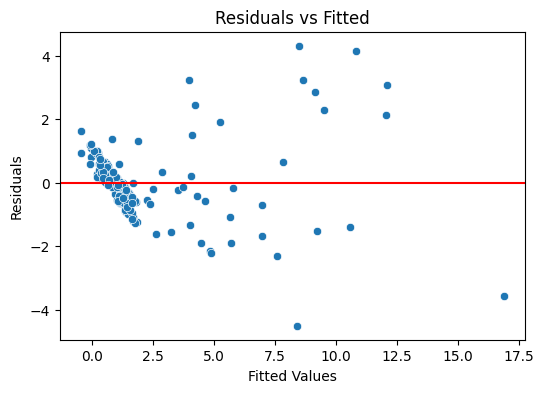

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

resid = reduced_model.resid
fitted = reduced_model.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color='red')
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.show()


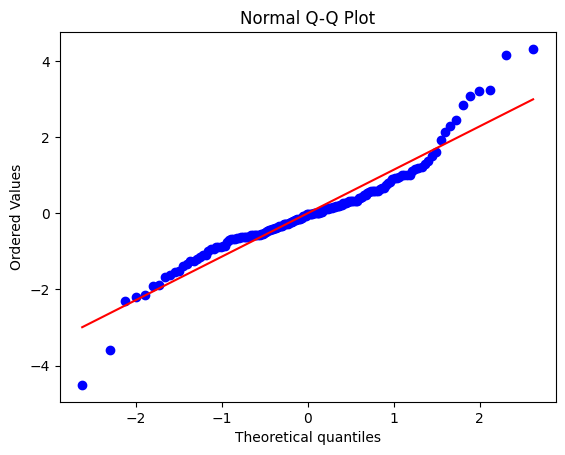

In [10]:
import scipy.stats as stats

stats.probplot(resid, dist="norm", plot=plt)
plt.title("Normal Q-Q Plot")
plt.show()


In [11]:
import numpy as np

rmse = np.sqrt(np.mean(resid**2))
print("RMSE:", rmse)


RMSE: 1.1736201275557634
